In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Dense,
    Flatten,
    Input,
    Activation
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score-
)

print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2


In [12]:
# ============================================
# Load CIFAR-10 Dataset
# ============================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)


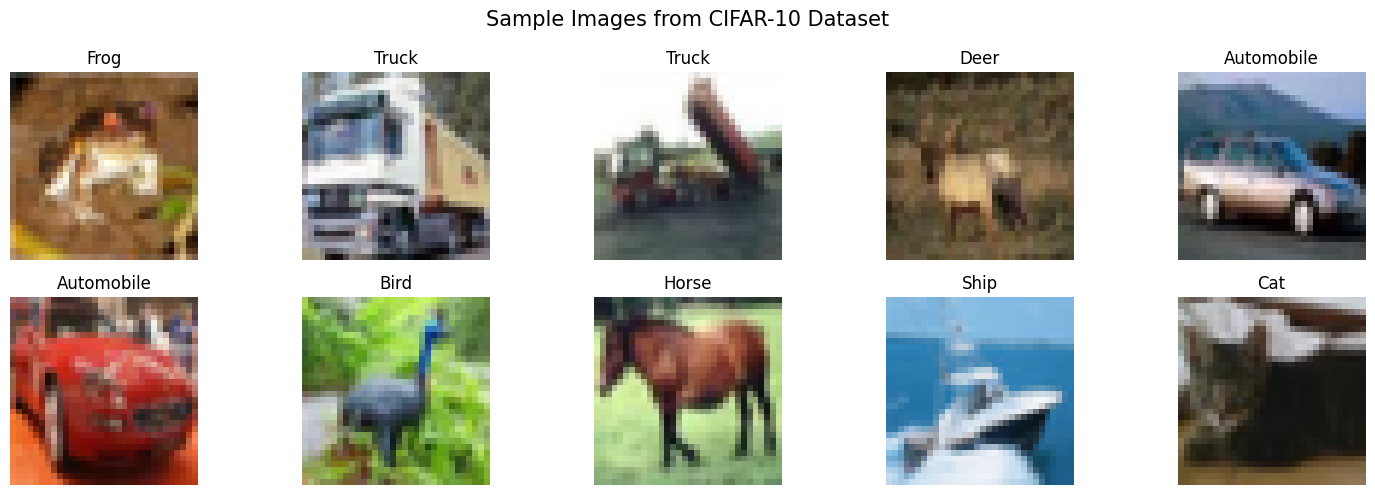

In [13]:
# ============================================
# Display Sample Images
# ============================================

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

plt.figure(figsize=(15,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=15)
plt.tight_layout()
plt.show()

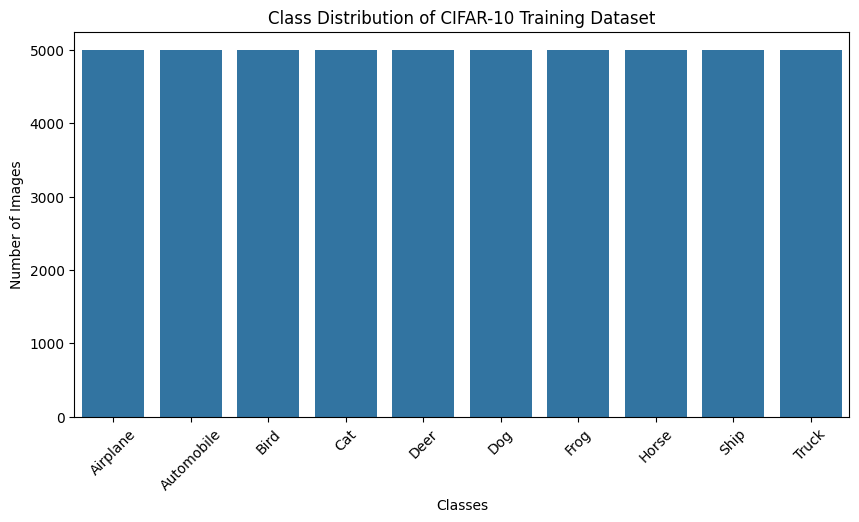


Images per Class

Airplane     : 5000
Automobile   : 5000
Bird         : 5000
Cat          : 5000
Deer         : 5000
Dog          : 5000
Frog         : 5000
Horse        : 5000
Ship         : 5000
Truck        : 5000


In [14]:
# ============================================
# Class Distribution
# ============================================

unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))

sns.barplot(x=class_names, y=counts)

plt.title("Class Distribution of CIFAR-10 Training Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

print("\nImages per Class\n")

for cls, cnt in zip(class_names, counts):
    print(f"{cls:12s} : {cnt}")

In [15]:
# ============================================
# Data Preprocessing
# ============================================

# Normalize pixel values to [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-Hot Encode Labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Training Image Shape :", X_train.shape)
print("Testing Image Shape  :", X_test.shape)

print("Training Labels Shape :", y_train_cat.shape)
print("Testing Labels Shape  :", y_test_cat.shape)

print("\nData preprocessing completed successfully.")

Training Image Shape : (50000, 32, 32, 3)
Testing Image Shape  : (10000, 32, 32, 3)
Training Labels Shape : (50000, 10)
Testing Labels Shape  : (10000, 10)

Data preprocessing completed successfully.


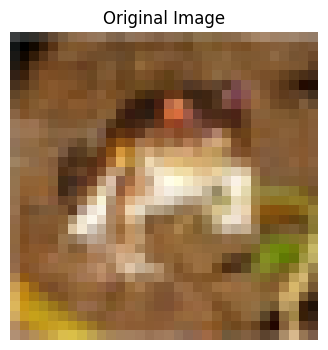

Image Shape : (32, 32, 3)


In [16]:
# ============================================
# Select a Sample Image
# ============================================

sample_image = X_train[0]

plt.figure(figsize=(4,4))
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis("off")
plt.show()

print("Image Shape :", sample_image.shape)

In [17]:
# ============================================
# Compare Different Kernel Sizes
# ============================================

kernel_sizes = [3, 5, 7]

print("Feature Map Sizes\n")

for k in kernel_sizes:

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32,32,3)),
        tf.keras.layers.Conv2D(
            filters=1,
            kernel_size=(k,k),
            strides=1,
            padding='valid',
            use_bias=False
        )
    ])

    feature_map = model.predict(sample_image[np.newaxis, ...], verbose=0)

    print(f"Kernel {k}x{k} ---> {feature_map.shape}")

Feature Map Sizes

Kernel 3x3 ---> (1, 30, 30, 1)
Kernel 5x5 ---> (1, 28, 28, 1)
Kernel 7x7 ---> (1, 26, 26, 1)


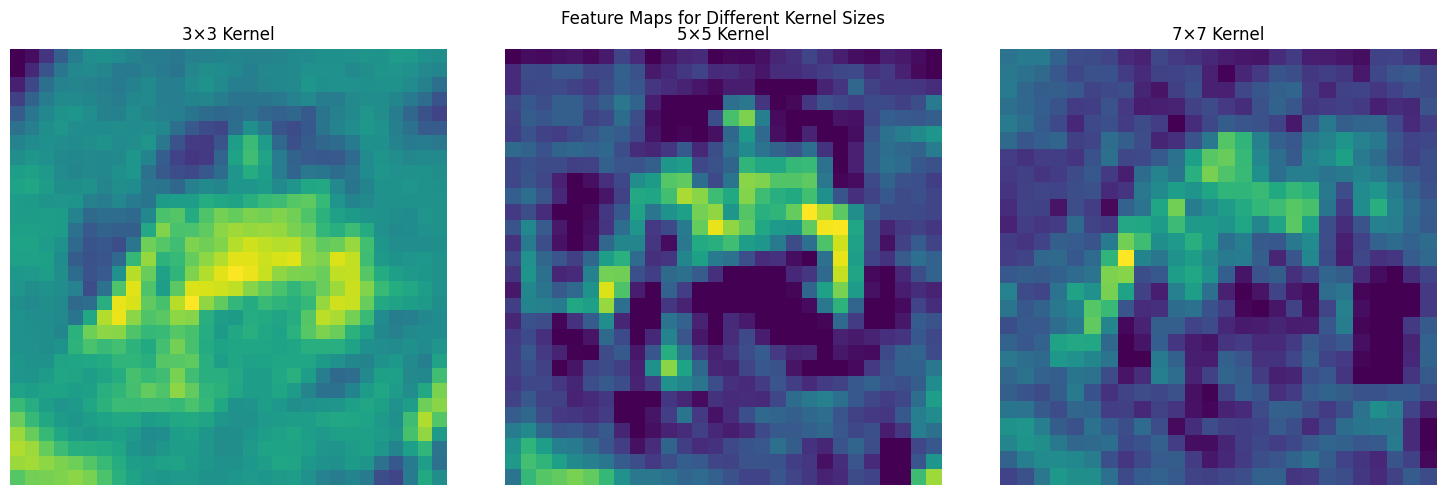

In [18]:
# ============================================
# Visualize Feature Maps
# ============================================

kernel_sizes = [3,5,7]

plt.figure(figsize=(15,5))

for i,k in enumerate(kernel_sizes):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32,32,3)),
        tf.keras.layers.Conv2D(
            filters=1,
            kernel_size=(k,k),
            padding='valid',
            activation='relu'
        )
    ])

    feature = model.predict(sample_image[np.newaxis,...], verbose=0)

    plt.subplot(1,3,i+1)
    plt.imshow(feature[0,:,:,0], cmap='viridis')
    plt.title(f"{k}×{k} Kernel")
    plt.axis("off")

plt.suptitle("Feature Maps for Different Kernel Sizes")
plt.tight_layout()
plt.show()

In [19]:
# ============================================
# Compare Stride and Padding
# ============================================

settings = [
    (1,'valid'),
    (2,'valid'),
    (1,'same'),
    (2,'same')
]

for stride,padding in settings:

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32,32,3)),
        tf.keras.layers.Conv2D(
            filters=1,
            kernel_size=(3,3),
            strides=stride,
            padding=padding
        )
    ])

    output = model.predict(sample_image[np.newaxis,...], verbose=0)

    print(f"Stride = {stride} | Padding = {padding.upper()} --> {output.shape}")

Stride = 1 | Padding = VALID --> (1, 30, 30, 1)
Stride = 2 | Padding = VALID --> (1, 15, 15, 1)
Stride = 1 | Padding = SAME --> (1, 32, 32, 1)
Stride = 2 | Padding = SAME --> (1, 16, 16, 1)


In [20]:
# ============================================
# Output Dimension Calculator
# ============================================

def output_size(N, F, S, P):
    return ((N - F + 2*P) // S) + 1

N = 32
F = 3

cases = [
    ("Stride=1, Padding=Valid",1,0),
    ("Stride=2, Padding=Valid",2,0),
    ("Stride=1, Padding=Same",1,1),
    ("Stride=2, Padding=Same",2,1)
]

print("Output Dimension Calculation\n")

for name,S,P in cases:
    out = output_size(N,F,S,P)
    print(f"{name:30s} : {out} x {out}")

Output Dimension Calculation

Stride=1, Padding=Valid        : 30 x 30
Stride=2, Padding=Valid        : 15 x 15
Stride=1, Padding=Same         : 32 x 32
Stride=2, Padding=Same         : 16 x 16


In [21]:
# ============================================
# Build Model for Feature Map Visualization
# ============================================

feature_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(
        filters=8,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        name='First_Conv_Layer'
    )
])

# Generate Feature Maps
feature_maps = feature_model.predict(sample_image[np.newaxis, ...], verbose=0)

print("Feature Map Shape :", feature_maps.shape)

Feature Map Shape : (1, 32, 32, 8)


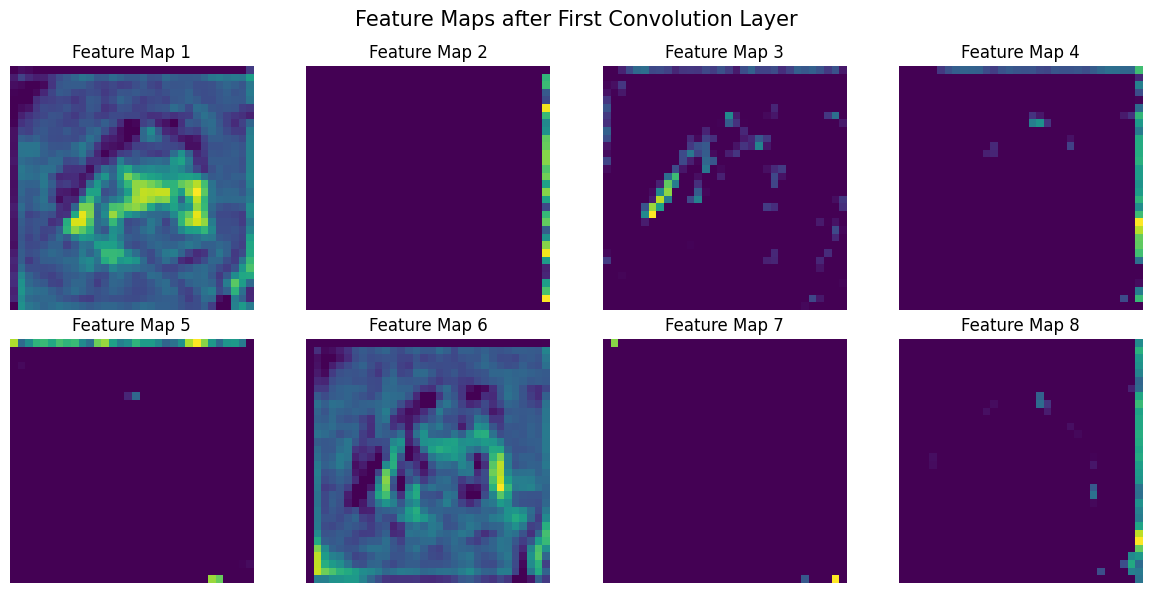

In [22]:
# ============================================
# Display Feature Maps
# ============================================

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
    plt.title(f"Feature Map {i+1}")
    plt.axis("off")

plt.suptitle("Feature Maps after First Convolution Layer", fontsize=15)
plt.tight_layout()
plt.show()

In [23]:
# ============================================
# Compare Max Pooling and Average Pooling
# ============================================

pool_input = tf.random.normal((1,32,32,1))

max_pool = tf.keras.layers.MaxPooling2D(pool_size=(2,2))
avg_pool = tf.keras.layers.AveragePooling2D(pool_size=(2,2))

max_output = max_pool(pool_input)
avg_output = avg_pool(pool_input)

print("Input Shape           :", pool_input.shape)
print("Max Pool Output Shape :", max_output.shape)
print("Avg Pool Output Shape :", avg_output.shape)

Input Shape           : (1, 32, 32, 1)
Max Pool Output Shape : (1, 16, 16, 1)
Avg Pool Output Shape : (1, 16, 16, 1)


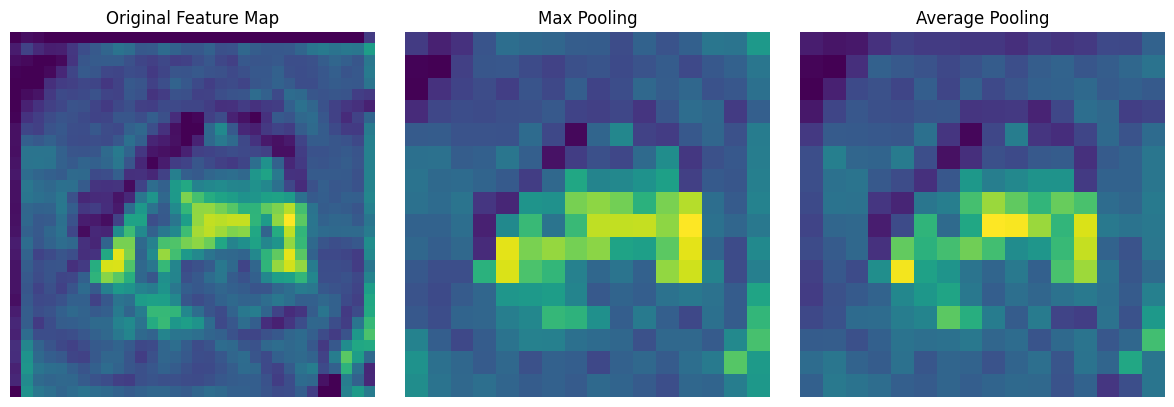

In [24]:
# ============================================
# Visualize Pooling Outputs
# ============================================

# Apply pooling on the first feature map
first_feature = feature_maps[:,:,:,0:1]

max_result = tf.keras.layers.MaxPooling2D(pool_size=(2,2))(first_feature)
avg_result = tf.keras.layers.AveragePooling2D(pool_size=(2,2))(first_feature)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(first_feature[0,:,:,0], cmap='viridis')
plt.title("Original Feature Map")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(max_result[0,:,:,0], cmap='viridis')
plt.title("Max Pooling")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(avg_result[0,:,:,0], cmap='viridis')
plt.title("Average Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# ============================================
# CNN Parameter Calculation
# ============================================

kernel_height = 3
kernel_width = 3
input_channels = 3
filters = 16

parameters = ((kernel_height * kernel_width * input_channels) + 1) * filters

print("Kernel Size      :", f"{kernel_height}x{kernel_width}")
print("Input Channels   :", input_channels)
print("Number of Filters:", filters)
print("Trainable Parameters =", parameters)

Kernel Size      : 3x3
Input Channels   : 3
Number of Filters: 16
Trainable Parameters = 448


In [26]:
# ============================================
# Build CNN Model
# ============================================

cnn_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(32, 32, 3)),

    # First Convolution Block
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Block
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),

    # Fully Connected Layers
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ============================================
# Compile CNN Model
# ============================================

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [28]:
# ============================================
# Train CNN Model
# ============================================

history = cnn_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 107s 67ms/step - accuracy: 0.5063 - loss: 1.3813 - val_accuracy: 0.6111 - val_loss: 1.1048
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 99s 63ms/step - accuracy: 0.6414 - loss: 1.0206 - val_accuracy: 0.6506 - val_loss: 1.0005
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 61ms/step - accuracy: 0.6930 - loss: 0.8828 - val_accuracy: 0.6571 - val_loss: 0.9780
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 61ms/step - accuracy: 0.7256 - loss: 0.7859 - val_accuracy: 0.6908 - val_loss: 0.8846
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 61ms/step - accuracy: 0.7554 - loss: 0.7028 - val_accuracy: 0.6978 - val_loss: 0.8990
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 62ms/step - accuracy: 0.7818 - loss: 0.6240 - val_accuracy: 0.7022 - val_loss: 0.9036
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.8083 - loss: 0.5496 - val_accuracy: 0.6897 - val_loss: 0.9640
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 61ms/step - accuracy: 0.82

In [29]:
# ============================================
# Evaluate CNN Model
# ============================================

test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

Test Loss     : 2.1665
Test Accuracy : 68.40%


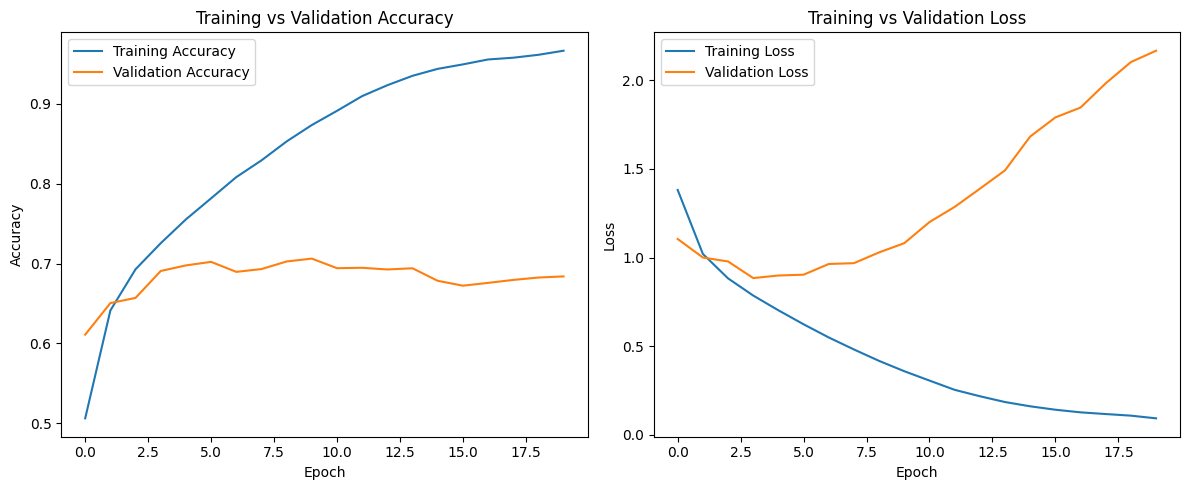

In [30]:
# ============================================
# Plot Accuracy and Loss Curves
# ============================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
# ============================================
# Predict Test Images
# ============================================

y_pred_prob = cnn_model.predict(X_test, verbose=1)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

print("Prediction completed.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Prediction completed.


In [32]:
# ============================================
# Performance Metrics
# ============================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Model Performance")
print("-"*40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Performance
----------------------------------------
Accuracy : 0.6840
Precision: 0.6851
Recall   : 0.6840
F1 Score : 0.6833


In [33]:
# ============================================
# Classification Report
# ============================================

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.65      0.79      0.71      1000
  Automobile       0.80      0.81      0.80      1000
        Bird       0.56      0.56      0.56      1000
         Cat       0.52      0.48      0.50      1000
        Deer       0.63      0.65      0.64      1000
         Dog       0.60      0.57      0.59      1000
        Frog       0.72      0.75      0.73      1000
       Horse       0.73      0.76      0.74      1000
        Ship       0.84      0.75      0.79      1000
       Truck       0.80      0.73      0.76      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



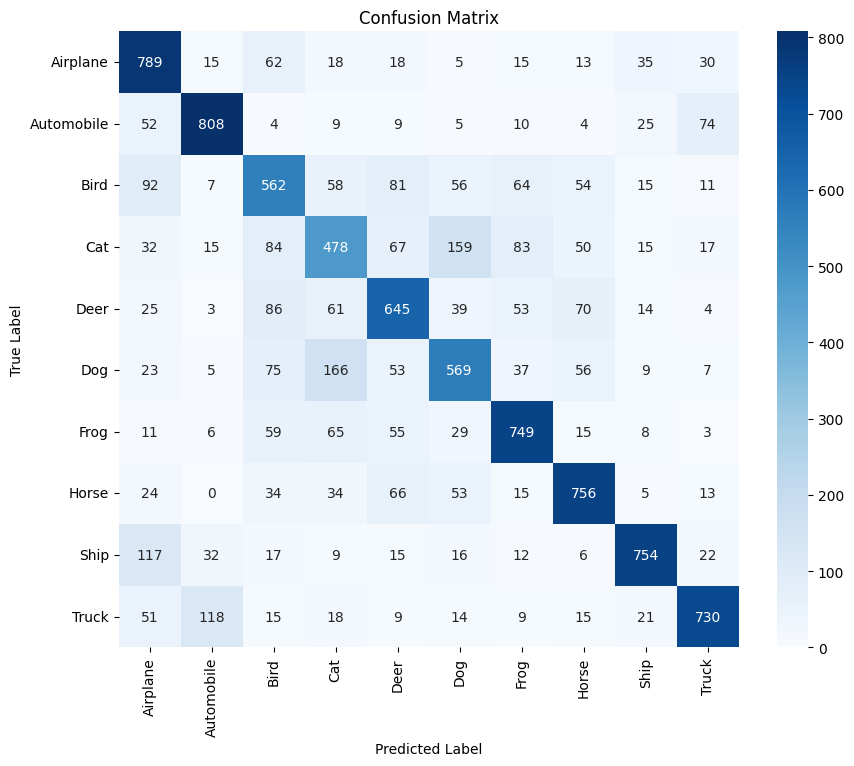

In [34]:
# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

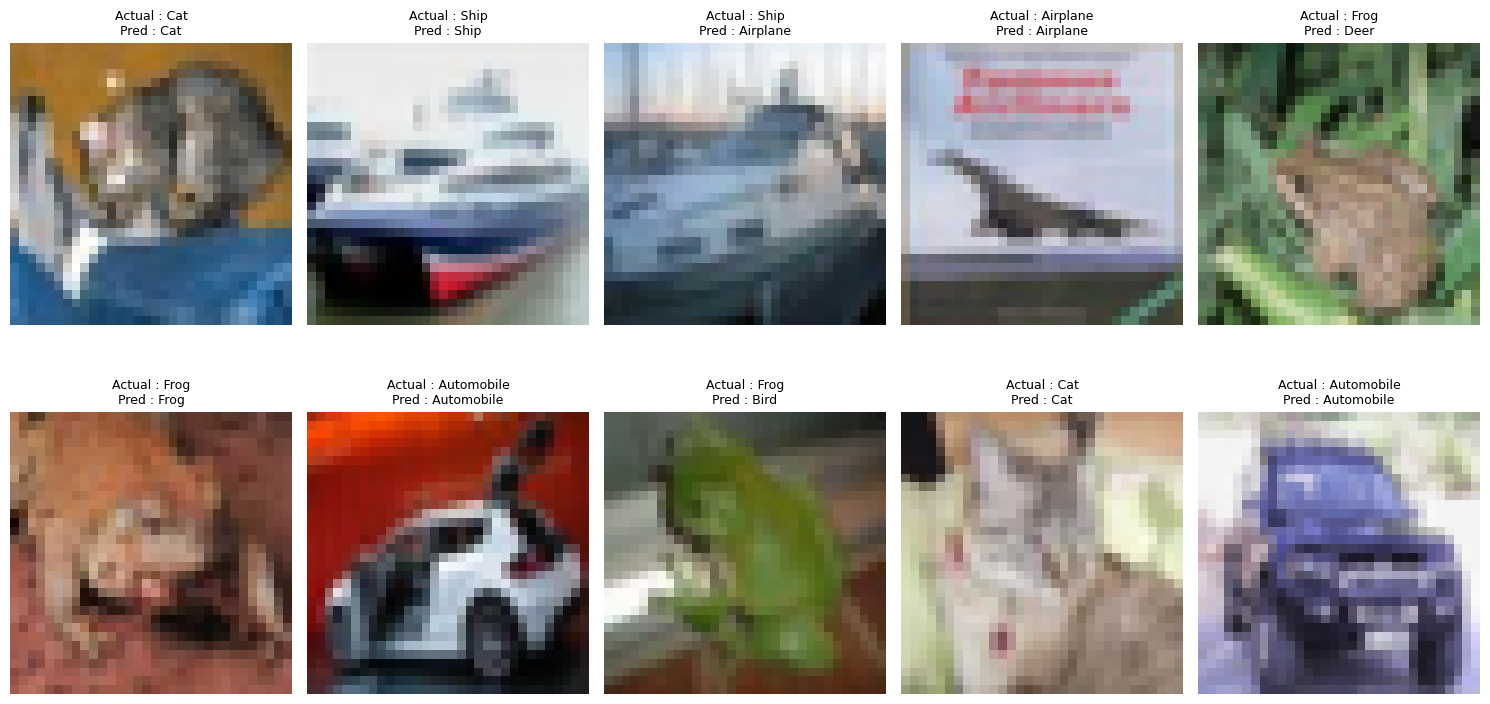

In [35]:
# ============================================
# Display Predictions
# ============================================

plt.figure(figsize=(15,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"Actual : {class_names[y_true[i]]}\nPred : {class_names[y_pred[i]]}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [36]:
# ============================================
# CNN with Average Pooling
# ============================================

avg_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(32,32,3)),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.AveragePooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.AveragePooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),

    tf.keras.layers.Dense(10,activation='softmax')

])

avg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_avg = avg_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test,y_test_cat),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 53ms/step - accuracy: 0.4838 - loss: 1.4390 - val_accuracy: 0.5661 - val_loss: 1.2193
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 53ms/step - accuracy: 0.6163 - loss: 1.0888 - val_accuracy: 0.6278 - val_loss: 1.0484
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.6740 - loss: 0.9344 - val_accuracy: 0.6780 - val_loss: 0.9239
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.7096 - loss: 0.8253 - val_accuracy: 0.6808 - val_loss: 0.9031
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 53ms/step - accuracy: 0.7400 - loss: 0.7402 - val_accuracy: 0.7086 - val_loss: 0.8431
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.7652 - loss: 0.6637 - val_accuracy: 0.7124 - val_loss: 0.8456
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 53ms/step - accuracy: 0.7931 - loss: 0.5935 - val_accuracy: 0.7059 - val_loss: 0.8736
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.812

In [37]:
# ============================================
# Compare Pooling Accuracy
# ============================================

max_loss, max_acc = cnn_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

avg_loss, avg_acc = avg_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Pooling Comparison")
print("-"*40)

print(f"Max Pooling Accuracy     : {max_acc*100:.2f}%")
print(f"Average Pool Accuracy    : {avg_acc*100:.2f}%")

Pooling Comparison
----------------------------------------
Max Pooling Accuracy     : 68.40%
Average Pool Accuracy    : 70.95%


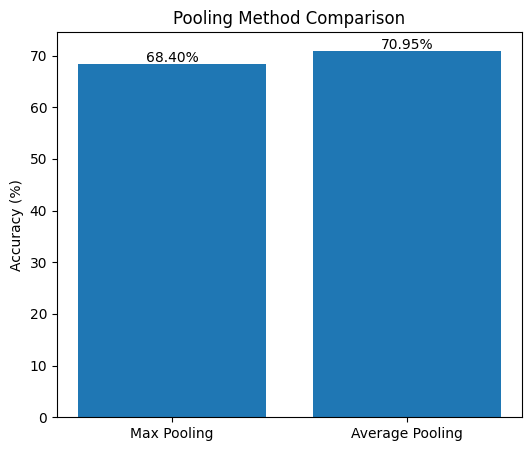

In [38]:
# ============================================
# Accuracy Comparison Graph
# ============================================

methods = ["Max Pooling","Average Pooling"]
accuracy = [max_acc*100, avg_acc*100]

plt.figure(figsize=(6,5))

plt.bar(methods, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Pooling Method Comparison")

for i,v in enumerate(accuracy):
    plt.text(i,v+0.3,f"{v:.2f}%",ha='center')

plt.show()

In [39]:
# ============================================
# Additional Exercise 1
# Output Size Calculation
# ============================================

N = 64       # Input size
F = 5        # Kernel size
S = 2        # Stride
P = 2        # Padding

output_size = ((N - F + 2 * P) // S) + 1

print("Input Size     :", N, "x", N)
print("Kernel Size    :", F, "x", F)
print("Stride         :", S)
print("Padding        :", P)

print("\nOutput Size    :", output_size, "x", output_size)

Input Size     : 64 x 64
Kernel Size    : 5 x 5
Stride         : 2
Padding        : 2

Output Size    : 32 x 32


In [40]:
# ============================================
# Additional Exercise 2
# Trainable Parameters of Convolution Layer
# ============================================

filters = 64
kernel_height = 3
kernel_width = 3
input_channels = 3       # RGB

parameters_per_filter = (
    kernel_height *
    kernel_width *
    input_channels
) + 1                    # +1 for bias

total_parameters = parameters_per_filter * filters

print("Number of Filters :", filters)
print("Kernel Size       :", "3 x 3")
print("Input Channels    :", input_channels)
print("Parameters/Filter :", parameters_per_filter)
print("Total Parameters  :", total_parameters)

Number of Filters : 64
Kernel Size       : 3 x 3
Input Channels    : 3
Parameters/Filter : 28
Total Parameters  : 1792


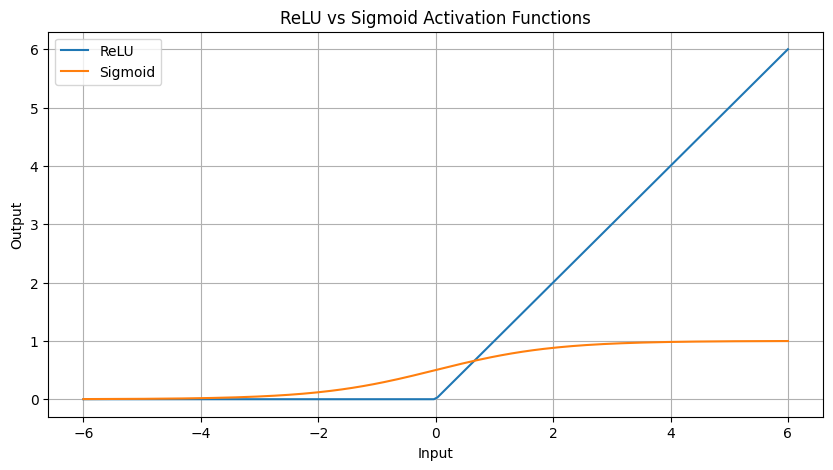

In [41]:
# ============================================
# Additional Exercise 3
# Compare ReLU and Sigmoid
# ============================================

x = np.linspace(-6, 6, 200)

relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(10,5))

plt.plot(x, relu, label="ReLU")
plt.plot(x, sigmoid, label="Sigmoid")

plt.title("ReLU vs Sigmoid Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()

plt.show()

In [42]:
# ============================================
# Additional Exercise 5
# CNN with 16 Filters
# ============================================

import time

model_16 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(32,32,3)),

    tf.keras.layers.Conv2D(
        16,
        (3,3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

model_16.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_16.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,434 (2.04 MB)

 Trainable params: 535,434 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# ============================================
# Train 16-Filter CNN
# ============================================

start_time_16 = time.time()

history_16 = model_16.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32,
    verbose=1
)

time_16 = time.time() - start_time_16

loss_16, accuracy_16 = model_16.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("\n16-Filter CNN Results")
print("-" * 40)
print(f"Testing Accuracy : {accuracy_16 * 100:.2f}%")
print(f"Training Time    : {time_16:.2f} seconds")

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.4986 - loss: 1.4053 - val_accuracy: 0.6096 - val_loss: 1.1185
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 45ms/step - accuracy: 0.6355 - loss: 1.0441 - val_accuracy: 0.6559 - val_loss: 0.9907
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.6837 - loss: 0.9078 - val_accuracy: 0.6847 - val_loss: 0.9220
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.7144 - loss: 0.8172 - val_accuracy: 0.6863 - val_loss: 0.9094
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7399 - loss: 0.7424 - val_accuracy: 0.6923 - val_loss: 0.9149
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.7632 - loss: 0.6776 - val_accuracy: 0.6970 - val_loss: 0.9003
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.7855 - loss: 0.6097 - val_accuracy: 0.7045 - val_loss: 0.9055
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.8060 -

In [44]:
# ============================================
# CNN with 64 Filters
# ============================================

model_64 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(32,32,3)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

model_64.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_64.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,426 (2.15 MB)

 Trainable params: 564,426 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# ============================================
# Train 64-Filter CNN
# ============================================

start_time_64 = time.time()

history_64 = model_64.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=32,
    verbose=1
)

time_64 = time.time() - start_time_64

loss_64, accuracy_64 = model_64.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("\n64-Filter CNN Results")
print("-" * 40)
print(f"Testing Accuracy : {accuracy_64 * 100:.2f}%")
print(f"Training Time    : {time_64:.2f} seconds")

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 163s 103ms/step - accuracy: 0.5212 - loss: 1.3459 - val_accuracy: 0.6012 - val_loss: 1.1511
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 160s 102ms/step - accuracy: 0.6533 - loss: 0.9857 - val_accuracy: 0.6623 - val_loss: 0.9716
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 100ms/step - accuracy: 0.7047 - loss: 0.8462 - val_accuracy: 0.6716 - val_loss: 0.9353
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 100ms/step - accuracy: 0.7399 - loss: 0.7421 - val_accuracy: 0.7037 - val_loss: 0.8477
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 100ms/step - accuracy: 0.7716 - loss: 0.6505 - val_accuracy: 0.6987 - val_loss: 0.8846
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 97ms/step - accuracy: 0.8007 - loss: 0.5677 - val_accuracy: 0.7060 - val_loss: 0.8883
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 154s 98ms/step - accuracy: 0.8251 - loss: 0.4913 - val_accuracy: 0.7029 - val_loss: 0.9816
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 98ms/step - accur

In [46]:
# ============================================
# Compare 16 Filters vs 64 Filters
# ============================================

print("16 Filters vs 64 Filters")
print("=" * 45)

print(f"16 Filters - Accuracy : {accuracy_16 * 100:.2f}%")
print(f"64 Filters - Accuracy : {accuracy_64 * 100:.2f}%")

print()

print(f"16 Filters - Time     : {time_16:.2f} seconds")
print(f"64 Filters - Time     : {time_64:.2f} seconds")

print()

print(f"16 Filters - Parameters: {model_16.count_params():,}")
print(f"64 Filters - Parameters: {model_64.count_params():,}")

16 Filters vs 64 Filters
16 Filters - Accuracy : 67.59%
64 Filters - Accuracy : 66.18%

16 Filters - Time     : 1528.11 seconds
64 Filters - Time     : 3566.33 seconds

16 Filters - Parameters: 535,434
64 Filters - Parameters: 564,426


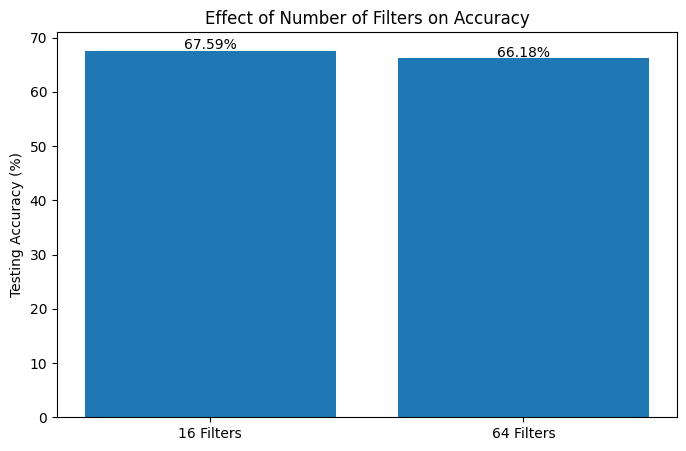

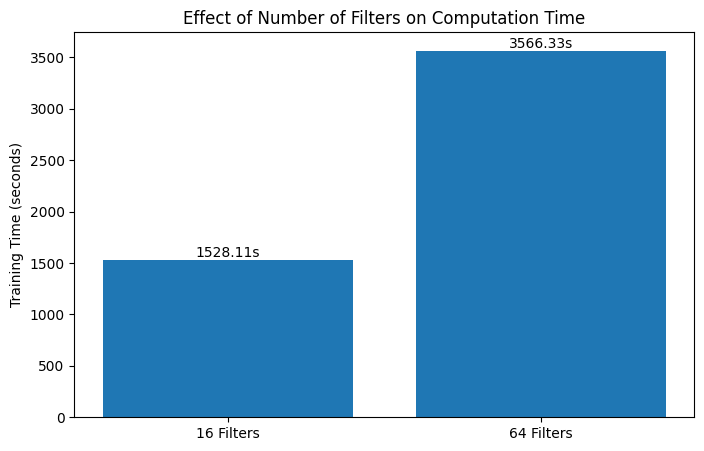

In [47]:
# ============================================
# Accuracy and Training Time Comparison
# ============================================

models = ["16 Filters", "64 Filters"]

accuracies = [
    accuracy_16 * 100,
    accuracy_64 * 100
]

times = [
    time_16,
    time_64
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Testing Accuracy (%)")
plt.title("Effect of Number of Filters on Accuracy")

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()


plt.figure(figsize=(8,5))

plt.bar(models, times)

plt.ylabel("Training Time (seconds)")
plt.title("Effect of Number of Filters on Computation Time")

for i, value in enumerate(times):
    plt.text(
        i,
        value,
        f"{value:.2f}s",
        ha="center",
        va="bottom"
    )

plt.show()